In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
stocks = [
    "ADANIENT.NS",
    "ADANIPORTS.NS",
    "APOLLOHOSP.NS",
    "ASIANPAINT.NS",
    "AXISBANK.NS",
    "BAJAJ-AUTO.NS",
    "BAJFINANCE.NS",
    "BEL.NS",
    "BHARTIARTL.NS",
    "CIPLA.NS",
    "COALINDIA.NS",
    "DRREDDY.NS",
    "EICHERMOT.NS",
    "ETERNAL.NS",   # formerly Zomato
    "GRASIM.NS",
    "HCLTECH.NS",
    "HDFCBANK.NS",
    "HDFCLIFE.NS",
    "HEROMOTOCO.NS",
    "HINDALCO.NS",
    "HINDUNILVR.NS",
    "ICICIBANK.NS",
    "INDUSINDBK.NS",
    "INFY.NS",
    "ITC.NS",
    "JIOFIN.NS",
    "JSWSTEEL.NS",
    "KOTAKBANK.NS",
    "LT.NS",
    "M&M.NS",
    "MARUTI.NS",
    "NESTLEIND.NS",
    "NTPC.NS",
    "ONGC.NS",
    "POWERGRID.NS",
    "RELIANCE.NS",
    "SBILIFE.NS",
    "SBIN.NS",
    "SHRIRAMFIN.NS",
    "SUNPHARMA.NS",
    "TATACONSUM.NS",
    "TATAMOTORS.NS",
    "TATASTEEL.NS",
    "TCS.NS",
    "TECHM.NS",
    "TITAN.NS",
    "TRENT.NS",
    "ULTRACEMCO.NS",
    "WIPRO.NS"
]




In [3]:
data = yf.download(
    stocks,
    start="2020-01-01",
   
    auto_adjust=True,
    progress=False
)["Close"]



HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


In [4]:
sector_map = {

    # Financials
    "HDFCBANK.NS": "Financials",
    "ICICIBANK.NS": "Financials",
    "AXISBANK.NS": "Financials",
    "KOTAKBANK.NS": "Financials",
    "SBIN.NS": "Financials",
    "BAJFINANCE.NS": "Financials",
    "SHRIRAMFIN.NS": "Financials",

    # IT
    "INFY.NS": "IT",
    "TCS.NS": "IT",
    "WIPRO.NS": "IT",
    "TECHM.NS": "IT",
    "HCLTECH.NS": "IT",

    # FMCG
    "ITC.NS": "FMCG",
    "HINDUNILVR.NS": "FMCG",
    "NESTLEIND.NS": "FMCG",
    "TATACONSUM.NS": "FMCG",

    # Auto
    "M&M.NS": "Auto",
    "MARUTI.NS": "Auto",
    "HEROMOTOCO.NS": "Auto",
    "BAJAJ-AUTO.NS": "Auto",

    # Metals
    "JSWSTEEL.NS": "Metals",
    "TATASTEEL.NS": "Metals",
    "HINDALCO.NS": "Metals",

    # Energy / PSU
    "COALINDIA.NS": "Energy",
    "NTPC.NS": "Energy",
    "RELIANCE.NS": "Energy",

    # Industrials
    "ADANIENT.NS": "Industrials",
    "TRENT.NS": "Retail",
    "ETERNAL.NS": "Retail",

    # Defence
    "BEL.NS": "Defence",

    # Pharma
    "SUNPHARMA.NS": "Pharma",

    # Telecom
    "BHARTIARTL.NS": "Telecom",

    # Others
    "JIOFIN.NS": "Financials",
    "INDUSINDBK.NS": "Financials",
    "GRASIM.NS": "Materials"
}



In [5]:
sector_prices = pd.DataFrame(index=data.index)

for sector in set(sector_map.values()):

    stocks = [
        stock
        for stock, sec in sector_map.items()
        if sec == sector
        and stock in data.columns
    ]

    sector_prices[sector] = data[stocks].mean(axis=1)

sector_prices.head()

,Materials,Metals,Industrials,FMCG,Pharma,Retail,IT,Financials,Energy,Auto,Defence,Telecom
Date,,,,,,,,,,,,
2020-01-01,716.887634,165.116020,205.794510,724.600735,406.074005,526.402710,725.582190,568.212660,294.569633,2997.373024,29.713720,433.316467
2020-01-02,739.914978,170.064119,209.111389,724.547363,406.681793,538.030884,724.462036,576.640455,298.189273,2995.834290,30.603794,435.132690
2020-01-03,730.549561,167.599475,206.240051,719.132420,415.704590,532.614380,737.168367,571.950504,298.069023,2966.672539,29.951078,435.037109
2020-01-06,711.577515,162.464397,197.576569,712.334816,411.356750,526.700867,734.804202,554.006054,291.531192,2894.541801,28.764309,429.827393
2020-01-07,716.694580,162.710711,202.032074,712.745441,417.387604,529.682434,735.573900,554.866812,295.388631,2898.526985,28.586290,425.477936


In [6]:
sector_momentum = (
    sector_prices
    .shift(21)
    .pct_change(252)
)

In [7]:
rebalance_dates = sector_momentum.index[252::21]

portfolio_returns = []

sector_history = {}



for i in range(len(rebalance_dates)-1):

    current_date = rebalance_dates[i]
    next_date = rebalance_dates[i+1]

    mom = sector_momentum.loc[current_date]

    top2_sectors = (
        mom
        .dropna()
        .nlargest(2)
        .index
    )

    sector_history[current_date] = list(top2_sectors)

    selected_stocks = []

    for sector in top2_sectors:

        stocks = [
            stock
            for stock, sec in sector_map.items()
            if sec == sector
            and stock in data.columns
        ]

        selected_stocks.extend(stocks)

    current_loc = data.index.get_loc(current_date)

    if current_loc + 1 >= len(data):
        continue

    entry_date = data.index[current_loc + 1]

    period_returns = (
        data.loc[
            entry_date:next_date,
            selected_stocks
        ]
        .pct_change()
        .mean(axis=1)
        .dropna()
    )

    portfolio_returns.append(period_returns)

In [8]:
portfolio_returns = pd.concat(portfolio_returns)

portfolio_returns = portfolio_returns[
    ~portfolio_returns.index.duplicated()
]

equity_curve = (
    1 + portfolio_returns
).cumprod()

In [9]:
# ============================================================
# PERFORMANCE METRICS
# ============================================================

strategy_return = (
    equity_curve.iloc[-1] - 1
) * 100

years = (
    equity_curve.index[-1]
    - equity_curve.index[0]
).days / 365.25

cagr = (
    equity_curve.iloc[-1]
) ** (1 / years) - 1

sharpe = (
    portfolio_returns.mean()
    / portfolio_returns.std()
) * np.sqrt(252)

running_max = equity_curve.cummax()

drawdown = (
    equity_curve
    / running_max
    - 1
)

max_drawdown = drawdown.min() * 100

print("=" * 60)
print("SECTOR ROTATION RESULTS")
print("=" * 60)

print(
    "Strategy Return:",
    round(strategy_return, 2),
    "%"
)

print(
    "CAGR:",
    round(cagr * 100, 2),
    "%"
)

print(
    "Sharpe:",
    round(sharpe, 2)
)

print(
    "Max Drawdown:",
    round(max_drawdown, 2),
    "%"
)

SECTOR ROTATION RESULTS
Strategy Return: 356.82 %
CAGR: 32.88 %
Sharpe: 1.17
Max Drawdown: -46.25 %


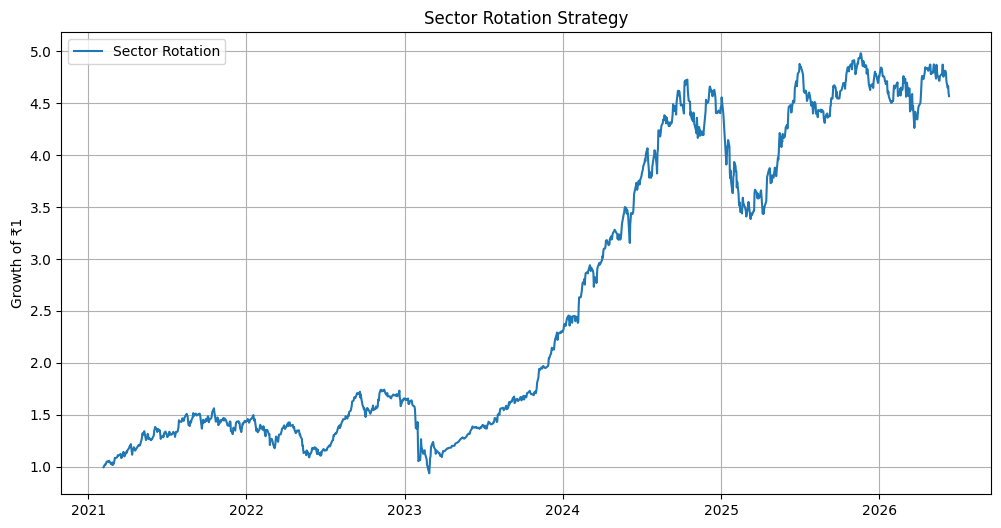

In [10]:
plt.figure(figsize=(12,6))

plt.plot(
    equity_curve,
    label="Sector Rotation"
)

plt.title(
    "Sector Rotation Strategy"
)

plt.ylabel(
    "Growth of ₹1"
)

plt.grid(True)
plt.legend()

plt.show()

In [11]:
sector_df = pd.DataFrame.from_dict(
    sector_history,
    orient="index"
)

sector_df.columns = [
    "Sector1",
    "Sector2"
]

sector_df.head(20)

,Sector1,Sector2
2021-01-04,NaN,NaN
2021-02-03,Industrials,IT
2021-03-04,Industrials,IT
2021-04-07,Industrials,Defence
2021-05-10,Industrials,Metals
2021-06-09,Industrials,Metals
2021-07-08,Industrials,Metals
2021-08-09,Industrials,Metals
2021-09-08,Industrials,Metals
2021-10-08,Industrials,Metals
